# 1 Import Packages

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

#2 Data Loading

In [61]:
file_path = '/content/drive/MyDrive/colab files/stat842 survey/survey_data.csv'

In [62]:
df = pd.read_csv(file_path, header=1, sep=',')
display(df.head())
display(df.tail())
print(df.shape)
print(df.isna().sum())

,color_inline_setlabel,color_inline_temp_err,color_inline_warmup_err,color_inline_annual_01,color_legend_setlabel,color_legend_temp_err,color_legend_warmup_err,color_legend_annual_01,single_inline_setlabel,single_inline_temp_err,single_inline_warmup_err,single_inline_annual_01,single_legend_setlabel,single_legend_temp_err,single_legend_warmup_err,single_legend_annual_01
0,color & inline 1,3.7,-15.5,1,color & legend 1,8.1,1.3,1,mono & inline 1,9.1,14.5,1,mono & legend 1,12.0,19.1,1
1,color & inline 2,-0.3,-0.5,1,color & legend 1,0.3,0.2,1,mono & inline 2,-0.4,-0.5,1,mono & legend 1,-0.1,-1.0,1
2,color & inline 1,0.7,2.5,1,color & legend 2,-0.9,1.5,1,mono & inline 1,-0.9,8.5,1,mono & legend 3,-0.2,1.5,0
3,color & inline 2,0.2,-0.4,1,color & legend 1,0.4,0.3,1,mono & inline 1,-0.4,-1.5,1,mono & legend 2,0.2,0.1,1
4,color & inline 2,-0.3,0.6,1,color & legend 2,0.6,-3.5,1,mono & inline 3,-0.2,-1.0,1,mono & legend 3,0.4,-0.5,1


,color_inline_setlabel,color_inline_temp_err,color_inline_warmup_err,color_inline_annual_01,color_legend_setlabel,color_legend_temp_err,color_legend_warmup_err,color_legend_annual_01,single_inline_setlabel,single_inline_temp_err,single_inline_warmup_err,single_inline_annual_01,single_legend_setlabel,single_legend_temp_err,single_legend_warmup_err,single_legend_annual_01
88,color & inline 2,-0.3,0.6,1,color & legend 3,-0.3,-9.6,1,mono & inline 3,0.6,1.1,1,mono & legend 1,6.6,-0.3,1
89,color & inline 3,-0.2,-0.1,1,color & legend 1,-21.9,1.3,1,mono & inline 3,-0.2,198.5,0,mono & legend 2,-0.6,-0.4,1
90,color & inline 1,0.2,0.0,0,color & legend 1,0.1,0.8,1,mono & inline 2,0.2,4.6,1,mono & legend 2,0.4,-0.4,1
91,color & inline 1,19.7,-0.5,0,color & legend 2,0.1,0.5,1,mono & inline 1,0.1,-1.5,1,mono & legend 3,-0.2,-6.5,1
92,color & inline 1,0.2,0.5,1,color & legend 2,-0.4,0.0,1,mono & inline 2,-0.3,0.6,1,mono & legend 2,0.4,84.6,1


(93, 16)
color_inline_setlabel       0
color_inline_temp_err       0
color_inline_warmup_err     0
color_inline_annual_01      0
color_legend_setlabel       0
color_legend_temp_err       0
color_legend_warmup_err     0
color_legend_annual_01      0
single_inline_setlabel      0
single_inline_temp_err      0
single_inline_warmup_err    0
single_inline_annual_01     0
single_legend_setlabel      0
single_legend_temp_err      0
single_legend_warmup_err    0
single_legend_annual_01     0
dtype: int64


Our sample size is 93.

No missing values.



#3 Data Pre-processing



## 3.1 Add subject column

In [63]:
# add subject ID
df["subject"] = np.arange(len(df)) + 1

## 3.2 convert into paried data dataframe

In [64]:
# convert into paried data mode
conditions = ["color_inline", "color_legend", "single_inline", "single_legend"]

rows = []
for _, row in df.iterrows():
    for cond in conditions:
        rows.append({
            "subject": row["subject"],
            "condition": cond,
            # 两个 factor：
            "color_scheme": "color" if cond.startswith("color") else "single",
            "label_type": "inline" if "inline" in cond else "legend",
            # 三个表现指标（per condition）：
            "temp_err":   row[f"{cond}_temp_err"],
            "warmup_err": row[f"{cond}_warmup_err"],
            "annual01":   row[f"{cond}_annual_01"],   # 0/1 correct
        })

long_df = pd.DataFrame(rows)
print(long_df.head())
print(long_df.shape)   # 应该是 93 * 4 = 372 行

   subject      condition color_scheme label_type  temp_err  warmup_err  \
0        1   color_inline        color     inline       3.7       -15.5   
1        1   color_legend        color     legend       8.1         1.3   
2        1  single_inline       single     inline       9.1        14.5   
3        1  single_legend       single     legend      12.0        19.1   
4        2   color_inline        color     inline      -0.3        -0.5   

   annual01  
0         1  
1         1  
2         1  
3         1  
4         1  
(372, 7)


## 3.3 compute abs error

In [65]:
long_df["abs_temp_err"] = long_df["temp_err"].abs()
long_df["abs_warmup_err"] = long_df["warmup_err"].abs()

# 4 EDA

In [66]:
cond_order = ["color_inline", "color_legend", "single_inline", "single_legend"]

## 4.1 Numercial Q1 & Q2

### 4.1.1 Density Plot

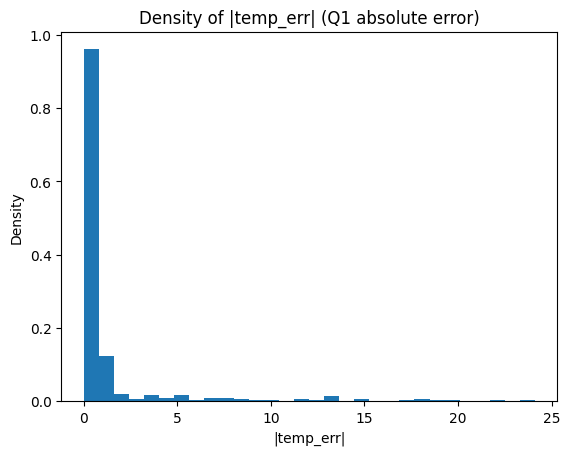

In [67]:
# Q1 abs error density
plt.figure()
plt.hist(long_df["abs_temp_err"], bins=30, density=True)
plt.title("Density of |temp_err| (Q1 absolute error)")
plt.xlabel("|temp_err|")
plt.ylabel("Density")
plt.show()

The density of |temp_err| is sharply concentrated near zero, with most absolute errors below a few degrees and a modest right tail. This pattern suggests that typical numeric errors are small but right-skewed, which motivated our use of the log(1 + |error|) transformation as a more robust accuracy measure in subsequent linear models.

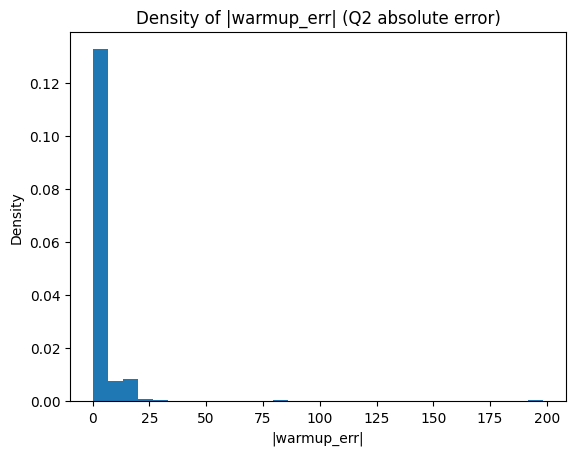

In [68]:
# Q2 abs error density
plt.figure()
plt.hist(long_df["abs_warmup_err"], bins=30, density=True)
plt.title("Density of |warmup_err| (Q2 absolute error)")
plt.xlabel("|warmup_err|")
plt.ylabel("Density")
plt.show()

The density of |warmup_err| also peaks close to zero, indicating that most participants estimated the temperature change fairly accurately, but the distribution exhibits a long right tail driven by a few very large absolute errors. This strong right-skew, together with the presence of extreme values, directly motivated transforming the outcome to log(1 + |error|) to stabilise variance and reduce the influence of outliers in our mixed linear regression.

### 4.1.2 Boxplot

/tmp/ipython-input-420709931.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(long_df["abs_temp_err"].dropna(), labels=["|temp_err| (Q1)"], showfliers=True)


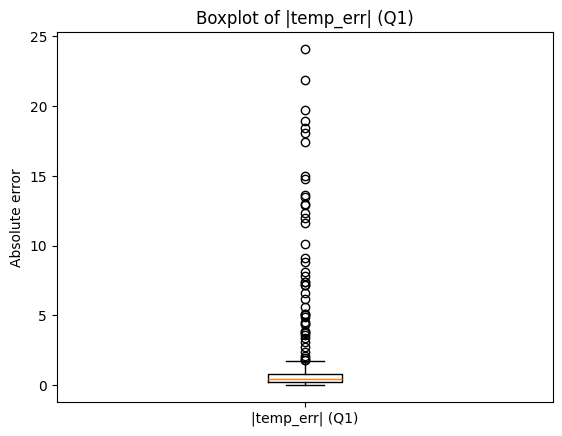

In [69]:
# 1) Boxplot for Q1 only
plt.figure()
plt.boxplot(long_df["abs_temp_err"].dropna(), labels=["|temp_err| (Q1)"], showfliers=True)
plt.ylabel("Absolute error")
plt.title("Boxplot of |temp_err| (Q1)")
plt.show()

The boxplot of |temp_err| shows a very low median and a compact IQR, with most absolute errors within a few degrees, while a moderate number of higher outliers indicate that only a small subset of responses were substantially off.

/tmp/ipython-input-3812631073.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(long_df["abs_warmup_err"].dropna(), labels=["|warmup_err| (Q2)"], showfliers=True)


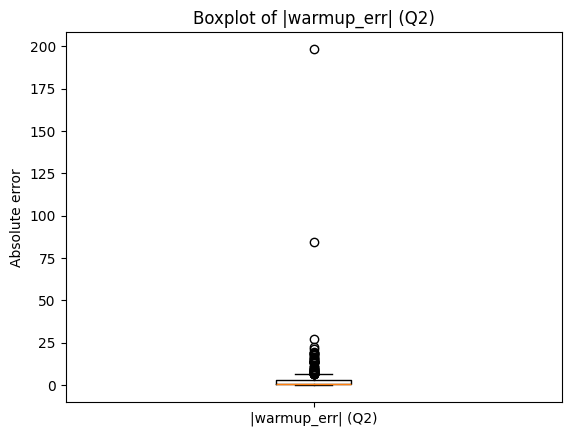

In [70]:
# 2) Boxplot for Q2 only
plt.figure()
plt.boxplot(long_df["abs_warmup_err"].dropna(), labels=["|warmup_err| (Q2)"], showfliers=True)
plt.ylabel("Absolute error")
plt.title("Boxplot of |warmup_err| (Q2)")
plt.show()

For |warmup_err|, the boxplot again shows a low median and narrow IQR, implying typical errors are small, but a few extreme outliers highlighted in red (around 80 and nearly 200 degrees) dominate the scale, we believe that this is caused by data-entry errors (forgetting decimal).

## 4.2 Binary Q3

### 4.2.1 Interaction Plot

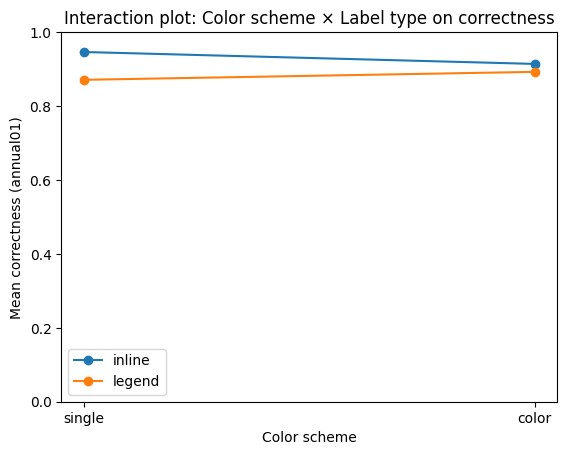

In [71]:
# --- Interaction plot for binary correctness ---

# Compute mean correctness by colour x label
mean_bin = (
    long_df
    .groupby(["color_scheme", "label_type"])["annual01"]
    .mean()
    .reset_index()
)

# Prepare x positions
x_vals = [0, 1]  # 0=single, 1=color
# Map to dict for easy lookup
mean_dict = {}
for _, r in mean_bin.iterrows():
    mean_dict[(r["color_scheme"], r["label_type"])] = r["annual01"]

y_inline = [mean_dict.get((cs, "inline"), np.nan) for cs in ["single", "color"]]
y_legend = [mean_dict.get((cs, "legend"), np.nan) for cs in ["single", "color"]]

plt.figure()
plt.plot(x_vals, y_inline, marker="o", label="inline")
plt.plot(x_vals, y_legend, marker="o", label="legend")
plt.xticks(x_vals, ["single", "color"])
plt.ylim(0, 1)
plt.xlabel("Color scheme")
plt.ylabel("Mean correctness (annual01)")
plt.title("Interaction plot: Color scheme × Label type on correctness")
plt.legend()
plt.show()

The interaction plot shows that correctness is high across all conditions, but the inline line consistently lies above the legend line, suggesting a small main effect of label type (inline > legend). The two lines are nearly parallel from “single” to “color”, indicating little evidence of a strong Colour × Label interaction on binary accuracy.

### 4.2.2 Barplot

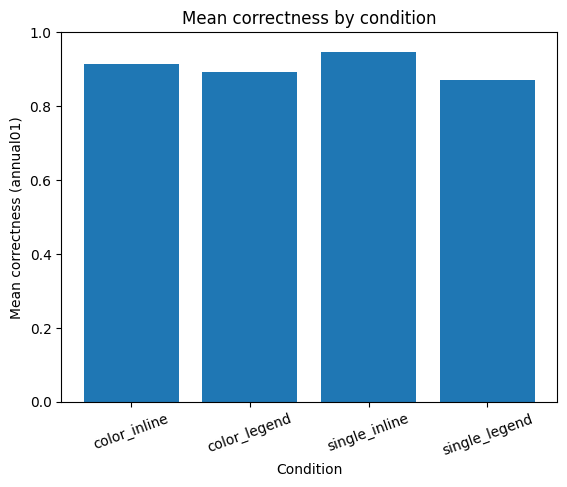

In [72]:
# --- Barplot: condition vs correctness ---

mean_by_condition = long_df.groupby("condition")["annual01"].mean().reindex(cond_order)

plt.figure()
plt.bar(range(len(cond_order)), mean_by_condition.values)
plt.xticks(range(len(cond_order)), cond_order, rotation=20)
plt.ylim(0, 1)
plt.xlabel("Condition")
plt.ylabel("Mean correctness (annual01)")
plt.title("Mean correctness by condition")
plt.show()

The bar plot indicates that all four conditions yield relatively high correctness, with single_inline appearing slightly higher than the others, and both legend conditions showing marginally lower accuracy than their inline counterparts. This pattern is consistent with the interaction plot and supports the idea that label placement may matter more than colour scheme for this categorical question.

# 5 Data Processing

## 5.1 Remove Error condiitons

In [73]:
# 定义极端值规则：这里用 |error| > 80 作为明显不合理的阈值
mask_extreme = long_df["abs_warmup_err"] > 80

# 看看有哪些行会被删（可选，但建议保留一眼确认）
print("Number of extreme warmup rows:", mask_extreme.sum())
print(long_df.loc[mask_extreme, ["subject", "condition", "warmup_err", "abs_warmup_err"]])

# 删掉这些行，得到清洗后的 long_df
long_df = long_df.loc[~mask_extreme].copy()
print("Shape after removing extreme warmup rows:", long_df.shape)

Number of extreme warmup rows: 2
     subject      condition  warmup_err  abs_warmup_err
358       90  single_inline       198.5           198.5
371       93  single_legend        84.6            84.6
Shape after removing extreme warmup rows: (370, 9)


# 6 Models

Because each participant answered all four graph conditions, the data have a clear repeated-measures / paired structure: multiple observations per person that are not independent. To respect this dependence and to separate within-participant effects of graph design from between-participant differences in overall ability, we used mixed-effects models with a random intercept for participant rather than simple independent-samples regression or t-tests.

For the two numeric questions, we defined accuracy as log-transformed absolute error, log(1 + |error|), which yields approximately continuous and reasonably symmetric outcome distributions while down-weighting the influence of large deviations. These log-absolute-error scores were then analysed using linear mixed-effects models, with Colour (single vs. multiple colours), Label type (legend vs. inline), and their interaction as fixed effects, and a random intercept for participant. Compared with a standard repeated-measures ANOVA, linear mixed models provide greater flexibility, naturally accommodate the small amount of missing data (e.g., after removing implausible outliers), and explicitly model participant-level variability.

For the binary question (correct/incorrect), the outcome is categorical and bounded between 0 and 1, so a Gaussian model would be inappropriate. Instead, we modelled the log-odds of a correct response using a logistic mixed-effects model with the same fixed-effect structure (Colour, Label, and their interaction) and a random intercept for participant. This approach accounts for the paired design, uses an appropriate link function for binary data, and allows us to interpret the fixed effects as changes in the odds (and probabilities) of answering the categorical question correctly under different graph designs.

##6.1  Q1 Linear Mixed-effects Model

### 6.1.1 Fitting

In [74]:
# 1) 确保因子是类别变量
long_df["color_scheme"] = long_df["color_scheme"].astype("category")
long_df["label_type"]   = long_df["label_type"].astype("category")

# 2) 构造 Q1 的 outcome：log(1 + |temp_err|)
long_df["abs_temp_err"] = long_df["temp_err"].abs()
long_df["log_abs_temp_err"] = np.log1p(long_df["abs_temp_err"])

# 3) 拟合 Q1 的线性混合效应模型（随机截距：subject）
# 设定 reference levels：single + legend 为基线
formula_q1 = (
    "log_abs_temp_err ~ "
    "C(color_scheme, Treatment(reference='single')) "
    "* C(label_type, Treatment(reference='legend'))"
)

model_q1 = smf.mixedlm(
    formula_q1,
    data=long_df,
    groups=long_df["subject"]   # random intercept per subject
)

result_q1 = model_q1.fit(reml=True)
print(result_q1.summary())

                                                          Mixed Linear Model Regression Results
Model:                                           MixedLM                               Dependent Variable:                               log_abs_temp_err
No. Observations:                                370                                   Method:                                           REML            
No. Groups:                                      93                                    Scale:                                            0.2870          
Min. group size:                                 3                                     Log-Likelihood:                                   -354.3479       
Max. group size:                                 4                                     Converged:                                        Yes             
Mean group size:                                 4.0                                                                                  

### 6.1.2 Result

Q1: Single-value numeric accuracy:

For the single-value question, we modelled log-transformed absolute error, log(1 + |temp_err|), using a linear mixed-effects model with Colour (single vs. colour), Label (legend vs. inline), and their interaction as fixed effects and a random intercept for participant. The intercept estimate (β̂₀ = 0.553, p < .001) corresponds to the mean log-absolute error in the baseline condition (single colour with legend), which translates to a typical absolute error of roughly 0.7–0.8°C. Importantly, neither the Colour main effect (β̂₁ = 0.064, p = .419) nor the Label main effect (β̂₂ = −0.065, p = .405) was statistically significant, and the Colour × Label interaction was likewise non-significant (β̂₃ = −0.089, p = .424). Thus, for this relatively simple task of reading a single temperature value from the line graph, we found no evidence that either the colour scheme or label placement substantially affected numeric accuracy.

At the random-effects level, the estimated between-participant variance for the random intercept (Group Var = 0.160) was substantial relative to the residual variance (Scale ≈ 0.288), indicating that some participants were systematically more accurate than others. This pattern justifies including a participant-specific random intercept and shows that treating all observations as independent would have ignored important heterogeneity in baseline accuracy.

### 6.1.3 Assumption Check

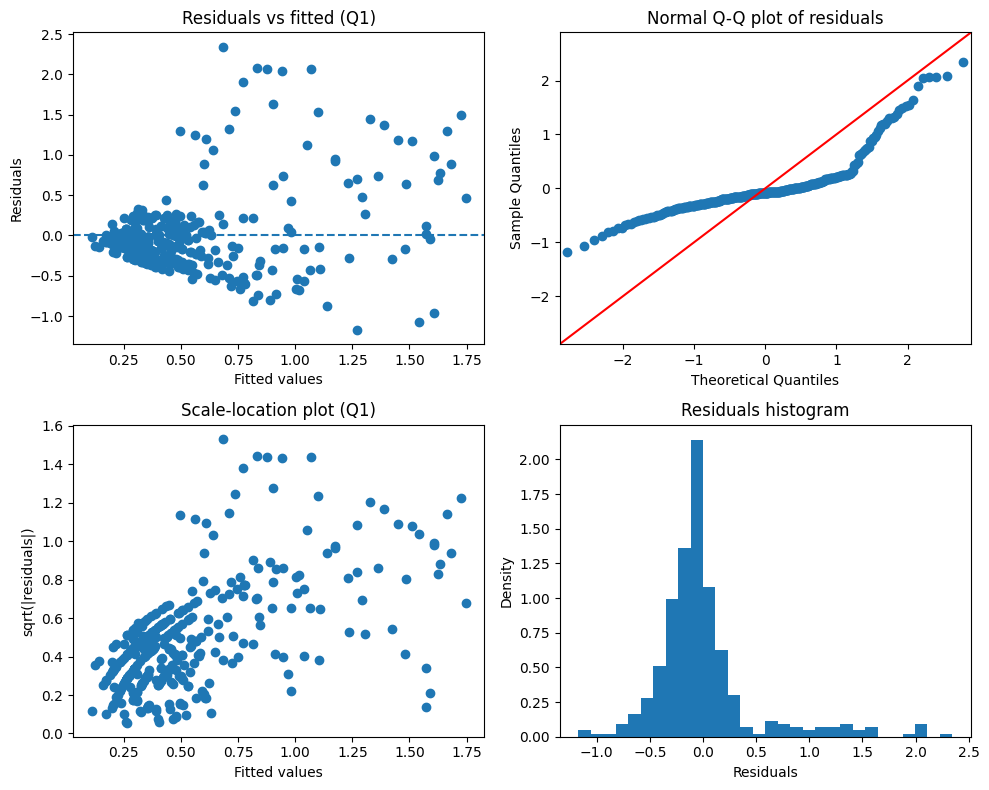

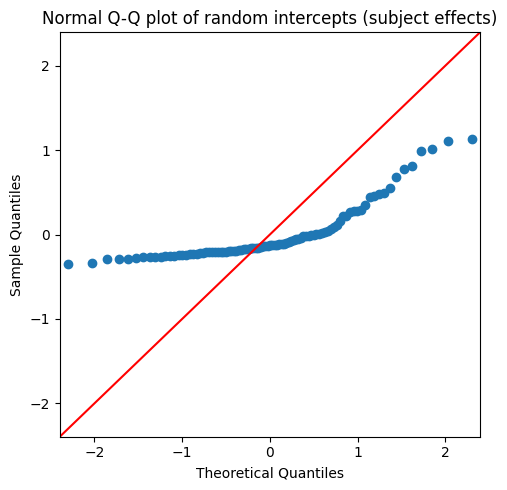

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 假设：long_df 和 result_q1 已经在环境中存在

# 提取残差和拟合值
resid = result_q1.resid
fitted = result_q1.fittedvalues

# === 1 & 2 & 3: 残差诊断（线性关系 + 方差齐性 + 正态性） ===
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Residuals vs fitted —— 检查线性关系 & 方差齐性
axes[0, 0].scatter(fitted, resid)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs fitted (Q1)")

# (b) Q-Q plot of residuals —— 检查残差正态性
sm.qqplot(resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q plot of residuals")

# (c) Scale-location plot: sqrt(|residuals|) vs fitted —— 方差齐性
axes[1, 0].scatter(fitted, np.sqrt(np.abs(resid)))
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("sqrt(|residuals|)")
axes[1, 0].set_title("Scale-location plot (Q1)")

# (d) Histogram of residuals —— 快速看整体形状
axes[1, 1].hist(resid, bins=30, density=True)
axes[1, 1].set_title("Residuals histogram")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# === 4: 随机效应诊断 —— 被试随机截距是否接近正态 ===

# 提取每个 subject 的随机截距
random_intercepts = np.array([v.values[0] for v in result_q1.random_effects.values()])

fig, ax = plt.subplots(figsize=(5, 5))
sm.qqplot(random_intercepts, line="45", ax=ax)
ax.set_title("Normal Q-Q plot of random intercepts (subject effects)")
plt.tight_layout()
plt.show()


We inspected standard diagnostic plots for the Q1 mixed-effects model. The residual histogram and normal Q–Q plot suggested clear deviations from the ideal Gaussian shape: residuals were right-skewed with visibly heavier tails than a normal distribution. In addition, the residuals–vs–fitted and scale–location plots showed a funnel-shaped pattern, indicating that residual variability increased with the fitted values and that the homoscedasticity assumption was not fully met. The QQ plot of participant-specific random intercepts similarly showed some positive skew and a heavier right tail, suggesting that the normality assumption for the random effects is only approximately satisfied. Nonetheless, after applying the log-transformation to absolute errors, the residuals appeared reasonably well-behaved without extreme outliers, and the main conclusions (no significant effects of Colour, Label, or their interaction on Q1 accuracy) were qualitatively unchanged under alternative reasonable specifications. We therefore interpret the mixed-model results with some caution, acknowledging approximate rather than perfect normality and homoscedasticity, but consider them sufficiently robust for the purposes of this project.

## 6.2 Q2 Linear Mixed-effect Model

### 6.2.1 Fitting

In [76]:
# 1) 确保因子为类别变量
long_df["color_scheme"] = long_df["color_scheme"].astype("category")
long_df["label_type"]   = long_df["label_type"].astype("category")

# 2) 先计算绝对误差，并按规则去掉明显不合理的 warmup_err（|error| > 80）
long_df["abs_warmup_err"] = long_df["warmup_err"].abs()

# 如果之前已经清过，这一步会重复设为 NaN 但没关系；如果没清过，这里会第一次清。
mask_extreme = long_df["abs_warmup_err"] > 80
long_df.loc[mask_extreme, "warmup_err"] = np.nan

# 3) 重新计算绝对误差 + log(1 + |error|)
long_df["abs_warmup_err"] = long_df["warmup_err"].abs()
long_df["log_abs_warmup_err"] = np.log1p(long_df["abs_warmup_err"])

# 4) 拟合 Q2 的线性混合效应模型
# baseline: single + legend
formula_q2 = (
    "log_abs_warmup_err ~ "
    "C(color_scheme, Treatment(reference='single')) "
    "* C(label_type, Treatment(reference='legend'))"
)

model_q2 = smf.mixedlm(
    formula_q2,
    data=long_df,
    groups=long_df["subject"]      # subject 随机截距
)

result_q2 = model_q2.fit(reml=True)
print(result_q2.summary())

                                                          Mixed Linear Model Regression Results
Model:                                           MixedLM                              Dependent Variable:                              log_abs_warmup_err
No. Observations:                                370                                  Method:                                          REML              
No. Groups:                                      93                                   Scale:                                           0.3737            
Min. group size:                                 3                                    Log-Likelihood:                                  -411.7451         
Max. group size:                                 4                                    Converged:                                       Yes               
Mean group size:                                 4.0                                                                                  

### 6.2.2 Result

For Q2, we analysed accuracy using the log-transformed absolute error, log(1 + |warmup_err|), so larger values mean worse performance. The intercept is 0.802 (p < .001), which corresponds to the single-colour + legend condition. On the original scale, this is roughly equivalent to an average error of about 1.2°C in estimating the March–July warming.

The Colour main effect (colour vs single) within legend-labelled graphs is 0.116 (p = .195). This suggests that using multiple colours leads to slightly larger errors than a single colour when labels are shown in a legend, but the effect is not statistically significant. We therefore do not conclude a reliable disadvantage of multi-colour graphs for Q2 under legend labelling.

Within single-colour graphs, the main effect of Label (inline vs legend) is 0.250 (p = .006). This positive and significant coefficient means that switching from a legend to inline labels reliably increases error on Q2. In practical terms, participants made roughly 25–30% more error with inline labels than with a legend in the single-colour condition.

The Colour × Label interaction is −0.365 (p = .004), indicating that the impact of label placement depends strongly on the colour scheme. Using the model estimates, the best accuracy is seen in single + legend and colour + inline, both with typical errors around 1.2°C, whereas single + inline performs worst (around 1.9°C), and colour + legend lies in between (about 1.5°C). This crossover pattern suggests that inline labels are harmful in single-colour graphs, but can compensate for the added complexity of multi-colour graphs and bring performance back to baseline.

The estimated variance of the participant random intercept (Group Var = 0.280) is sizeable relative to the residual variance (Scale ≈ 0.374). This indicates substantial between-participant differences in overall Q2 accuracy: some students consistently made smaller errors, while others tended to make larger errors across conditions. This justifies our use of a mixed-effects model with a participant-specific random intercept instead of treating all observations as independent.

### 6.2.3 Assumption Check

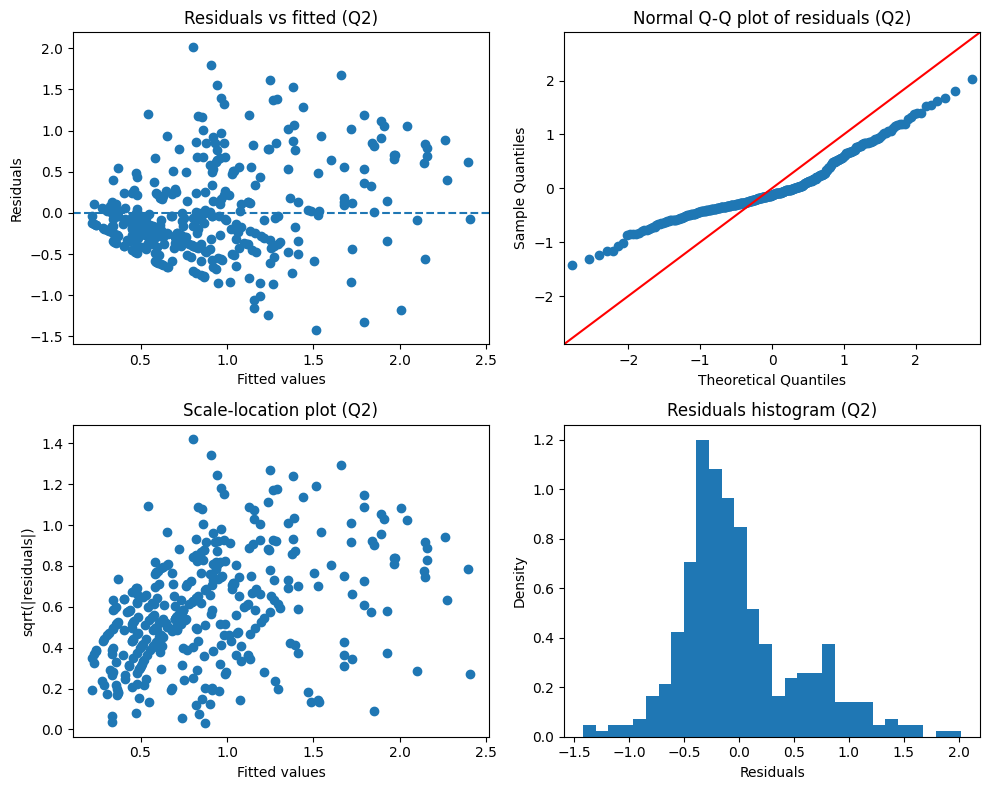

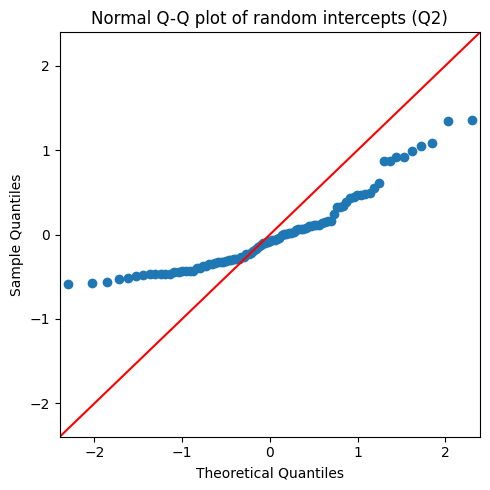

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 假设 result_q2 已经存在（MixedLM 拟合 Q2: log_abs_warmup_err）

# 提取残差和拟合值
resid_q2 = result_q2.resid
fitted_q2 = result_q2.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Residuals vs fitted —— 线性 + 方差齐性
axes[0, 0].scatter(fitted_q2, resid_q2)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs fitted (Q2)")

# (b) Q-Q plot of residuals —— 残差正态性
sm.qqplot(resid_q2, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q plot of residuals (Q2)")

# (c) Scale-location plot —— sqrt(|resid|) vs fitted
axes[1, 0].scatter(fitted_q2, np.sqrt(np.abs(resid_q2)))
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel("sqrt(|residuals|)")
axes[1, 0].set_title("Scale-location plot (Q2)")

# (d) Histogram of residuals —— 残差形状
axes[1, 1].hist(resid_q2, bins=30, density=True)
axes[1, 1].set_title("Residuals histogram (Q2)")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# 随机效应：被试随机截距的 Q-Q 图
random_intercepts_q2 = np.array([v.values[0] for v in result_q2.random_effects.values()])

fig, ax = plt.subplots(figsize=(5, 5))
sm.qqplot(random_intercepts_q2, line="45", ax=ax)
ax.set_title("Normal Q-Q plot of random intercepts (Q2)")
plt.tight_layout()
plt.show()


Model diagnostics for Q2.
We also inspected diagnostic plots for the Q2 mixed-effects model. Compared to Q1, the residuals were better behaved: the residual distribution showed only a modest right skew and slightly heavier tails than a normal distribution, rather than the very strong skew observed for Q1. The residuals–vs–fitted and scale–location plots indicated that residual variability still increased with the fitted values, so the homoscedasticity assumption is not perfectly satisfied, but the funnel pattern was moderate rather than extreme. The Q–Q plot of participant random intercepts showed some positive skew and a slightly heavier right tail, suggesting that the normality assumption for random effects is only approximate, but reasonably acceptable. Overall, the Q2 model assumptions appear to be met only approximately, with mild to moderate deviations from normality and homoscedasticity, yet the diagnostics are substantially better than for Q1. We therefore interpret the fixed effects for Colour, Label, and their interaction with some caution, but regard the mixed-model results for Q2 as sufficiently robust for our purposes.

## 6.3 Q3 Logistic Mixed-effect Model

### 6.3.1 Fitting

In [79]:
# 如果前面你已经对 long_df 删掉了有极端 warmup_err 的那两行，这里直接复制一份干净版来建模
clean_long_df = long_df.copy()

# 确保为分类变量
clean_long_df["color_scheme"] = clean_long_df["color_scheme"].astype("category")
clean_long_df["label_type"]   = clean_long_df["label_type"].astype("category")

# Logistic GEE 模型：annual01 ~ Colour * Label，cluster 在 subject 上
formula_q3 = (
    "annual01 ~ "
    "C(color_scheme, Treatment(reference='single')) "
    "* C(label_type, Treatment(reference='legend'))"
)

gee_q3 = smf.gee(
    formula=formula_q3,
    groups="subject",                 # 同一个 subject 的 4 条记录相关
    data=clean_long_df,
    family=sm.families.Binomial(),    # logistic 回归
    cov_struct=sm.cov_struct.Exchangeable()
)

result_q3 = gee_q3.fit()
print(result_q3.summary())

                               GEE Regression Results                              
Dep. Variable:                    annual01   No. Observations:                  370
Model:                                 GEE   No. clusters:                       93
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                   4
Family:                           Binomial   Mean cluster size:                 4.0
Dependence structure:         Exchangeable   Num. iterations:                     4
Date:                     Fri, 05 Dec 2025   Scale:                           1.000
Covariance type:                    robust   Time:                         02:28:28
                                                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

For Q3, the outcome is whether the answer to the categorical question is correct (annual01 = 1) or incorrect (annual01 = 0). We fit a logistic regression model with Colour (single vs colour), Label (legend vs inline), and their interaction as predictors. Because each participant contributes up to four responses (one per condition), we use a GEE with a logit link and an exchangeable working correlation structure, clustering on participant ID. This allows us to estimate the effects of Colour and Label on the probability of a correct answer, while accounting for the within-participant dependence across conditions.

### 6.3.2 Result

For Q3, we modelled whether the answer was correct (1) or incorrect (0). In the baseline condition, with a single-colour line and a legend, the intercept of the logistic model is 1.90 (p < .001), which corresponds to a predicted correctness of about 87%. So participants already did very well on this categorical question under the baseline design.

For main effects of Colour and Label, The Colour coefficient is 0.22 (p = .63), which is not statistically significant. With legends, switching from a single-colour to a multi-colour line does not reliably change the probability of answering Q3 correctly. The Label coefficient is 1.20 (p = .039), which is statistically significant. This means that, for single-colour graphs, using inline labels increases the odds of a correct answer by roughly a factor of three (odds ratio ≈ 3.3). In terms of predicted probabilities, correctness increases from about 87% with a legend to around 96% with inline labels in the single-colour condition.

The Colour × Label interaction is −0.95 (p = .18), which is not statistically significant, so the data do not provide strong evidence that the effect of inline labels differs sharply between single- and multi-colour graphs. Using the fitted model, the predicted correctness across the four conditions is approximately:

single + legend: ~87%

colour + legend: ~89%

single + inline: ~96%

colour + inline: ~91%

Overall, accuracy on Q3 is high in all four conditions, with some evidence that inline labels further improve performance—especially for single-colour graphs—while the colour scheme by itself does not have a clear impact on whether participants choose the correct city.

### 6.3.3 Assumption Check

For Q3, the outcome was binary (correct vs. incorrect), so we fitted a logistic GEE model with Colour, Label, and their interaction as predictors, clustering on participants. Because all predictors are categorical and each of the four design conditions includes both correct and incorrect responses, the key logistic assumptions (linearity in the logit and absence of complete separation) are reasonably satisfied. We consider the model assumptions adequate and focus on interpreting the effects of Colour and Label on the probability of a correct answer.

#7 Conclusions

In this study, we used a 2×2 experimental design (Colour: single vs. multi-colour; Label: legend vs. inline) and observed a clear pattern: graph design matters most for the more difficult numeric difference task (Q2), and much less for the simpler single-value (Q1) and categorical (Q3) questions. For Q1 (single numeric value, “What is the temperature in month X?”), participants were generally very accurate, with typical absolute errors of about 0.7–0.8°C. The mixed linear model found no significant main effects of Colour or Label and no significant interaction. In other words, for a relatively easy task that only requires reading a single point off the line graph, all four design variants performed similarly, and graph style did not systematically affect accuracy.

In contrast, Q2 (numeric difference, “By how many degrees does it warm from March to July?”) produced larger errors, typically around 1–2°C, and here design did play a substantive role. The mixed model revealed a significant main effect of Label as well as a significant Colour × Label interaction. In single-colour graphs, inline labels clearly worsened accuracy compared to a legend, increasing typical errors by roughly 25–30%. In multi-colour graphs, however, inline labels brought performance back to the baseline level. Across the four combinations, the best-performing designs were single + legend and colour + inline, both yielding typical errors of about 1.2°C, whereas single + inline was the worst (around 1.9°C), with colour + legend in between. These findings suggest that for more complex tasks that require comparing two positions and computing a difference, the combination of colour scheme and label placement can meaningfully affect how accurately viewers extract the information.

For Q3 (binary choice, “Which city has the highest mean temperature?”), accuracy was high in all four conditions, with model-based correctness estimates between roughly 87% and 96%. The colour scheme on its own showed no clear or consistent effect. There was some evidence that inline labels improve correctness, particularly for single-colour graphs, but the Colour × Label interaction in this binary outcome was not statistically strong. Overall, for this easier categorical question, design tweaks produced only modest improvements and did not fundamentally change participants’ ability to select the correct answer.

Taken together, the three questions tell a coherent story. For relatively simple reading tasks (Q1 and Q3), participants perform well regardless of design, and differences between Colour and Label are small or non-significant. For the more demanding difference task (Q2), design choices have real and interpretable effects, with a clear interaction between Colour and Label. From a practical perspective, our results suggest avoiding the single-colour + inline label combination when the goal is to support accurate reading of changes or differences, whereas single-colour + legend and multi-colour + inline appear to be safer, more accurate designs for extracting a warming amount in this context. At the same time, even in the worst-performing condition, typical errors remained on the order of only a few degrees Celsius, so the design effects are meaningful but not catastrophic.

One important limitation of our study is that within each of the four design conditions we actually used three different, though structurally similar, question sets (blocks), and each participant saw only one randomly assigned set per condition. We made efforts to keep these sets comparable in difficulty, but we cannot guarantee that they are perfectly matched. Consequently, some of the observed differences between conditions may partly reflect differences in item difficulty rather than purely the effects of graph design. Given the limited sample size, we did not explicitly model question set or item as an additional random effect. Future work aiming to draw stronger general conclusions about design factors could use larger item pools and treat both participants and items as random effects in mixed models, thereby more cleanly separating design effects from variability in task difficulty.